[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vicradon/ml-workspace/blob/main/shape_detection/notebook.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/vicradon/shape-detection)

In [41]:
IMAGE_DIMENSION=200

import os
os.environ["IMAGE_DIMENSION"] = str(IMAGE_DIMENSION)

In [42]:
%%bash
wget -qO shapegen https://github.com/vicradon/shapegen/releases/download/v0.0.1/shapegen-linux-amd64
cd /kaggle/working
chmod +x shapegen
./shapegen -size $IMAGE_DIMENSION -n 200
unzip -qo shape_dataset_coco.zip


  ╔═══════════════════════════════════════╗
  ║    Shape Dataset Generator  v1.0      ║
  ╚═══════════════════════════════════════╝

  Classes  : 7  (triangle, quadrilateral, pentagon, hexagon, heptagon, octagon, decagon)
  Images   : 200 per class  (1400 total)
  Size     : 200x200 px
  Format   : COCO
  Workers  : 4
  Output   : shape_dataset_coco.zip

  Generating images…
  done [████████████████████████████████████████] 100%  1400/1400 1400/1400
  ✓ Generated 1400 images in 1.945s

  Packing COCO ZIP…
  ✓ ZIP written in 214ms  (4.9 MB)

  ┌─────────────────────────────────────┐
  │  Output → shape_dataset_coco.zip    │
  └─────────────────────────────────────┘



In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

In [44]:
import json
from itertools import islice

with open("/kaggle/working/annotations/instances.json", "r") as annotation_data:
    content = annotation_data.read()
    
annotation_data = json.loads(content)

categories = pd.DataFrame(annotation_data["categories"])
images = pd.DataFrame(annotation_data["images"])
annotations = pd.DataFrame(annotation_data["annotations"])

In [45]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import numpy as np

img_to_label = annotations.groupby("image_id")["category_id"].first()
images["label"] = images["id"].map(img_to_label)

label_map = {cat_id: i for i, cat_id in enumerate(sorted(images["label"].unique()))}
images["label"] = images["label"].map(label_map)

class ShapeDataset(Dataset):
    def __init__(self, df, root_dir):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["file_name"])
        image = Image.open(img_path).convert("L")
        image = torch.tensor(np.array(image), dtype=torch.float32) / 255.0
        image = image.unsqueeze(0)
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, label

dataset = ShapeDataset(images, "/kaggle/working")

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

print({train_size, val_size, test_size})

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


{210, 979, 211}


In [46]:
categories

,id,name,supercategory
0,1,triangle,shape
1,2,quadrilateral,shape
2,3,pentagon,shape
3,4,hexagon,shape
4,5,heptagon,shape
5,6,octagon,shape
6,7,decagon,shape


In [47]:
images.head()

,id,file_name,width,height,label
0,1,images/triangle_0000.png,200,200,0
1,2,images/triangle_0001.png,200,200,0
2,3,images/triangle_0002.png,200,200,0
3,4,images/triangle_0003.png,200,200,0
4,5,images/triangle_0004.png,200,200,0


In [48]:
annotations.head()

,id,image_id,category_id,bbox,area,iscrowd
0,1,1,1,"[63.08, 59.17, 74.27, 76.23]",5661.64,0
1,2,2,1,"[93.43, 82.63, 79.73, 81.33]",6484.24,0
2,3,3,1,"[59.74, 76.26, 71.11, 80.18]",5701.46,0
3,4,4,1,"[46.79, 67.78, 63.78, 62.65]",3996.20,0
4,5,5,1,"[38.89, 58.35, 120.42, 105.93]",12755.28,0


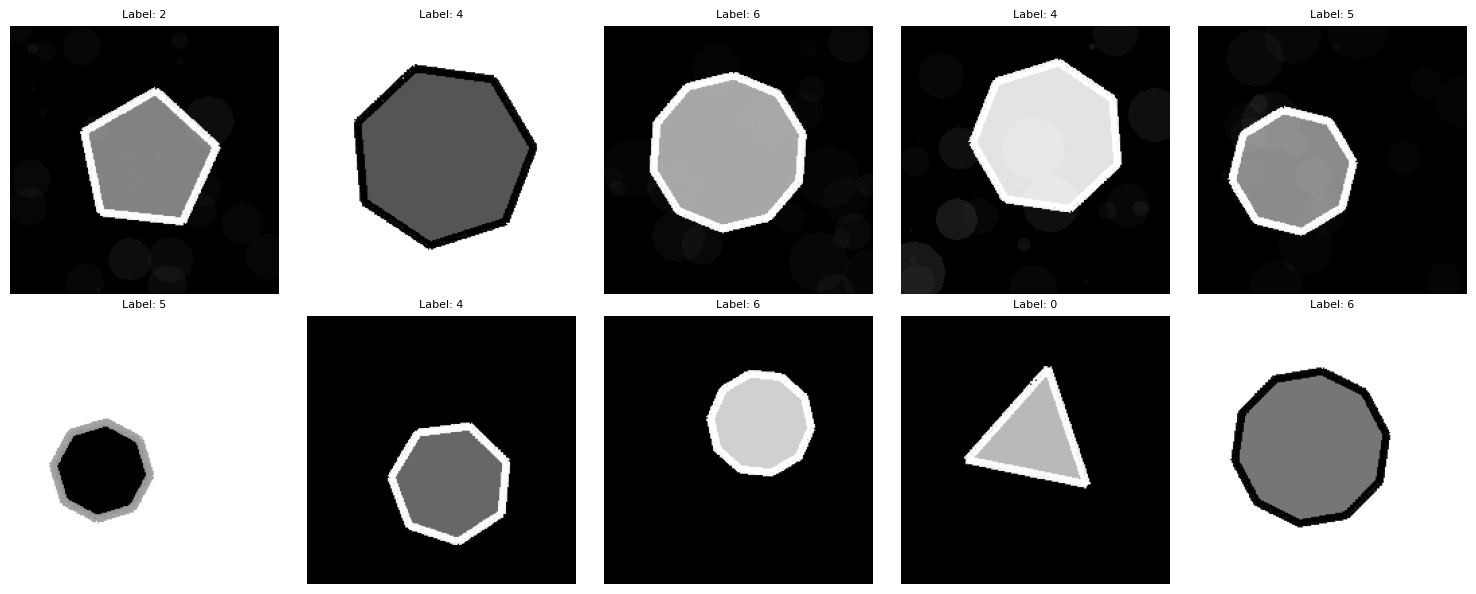

In [49]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))
images_batch, labels_batch = batch

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = images_batch[i].squeeze(0).numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {labels_batch[i].item()}", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [50]:
import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self, image_size, num_classes):
        super().__init__()
        self.image_size = image_size
        self.input_dim = image_size * image_size

        self.model = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), self.input_dim)
        return self.model(x)

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

network = NeuralNetwork(image_size=IMAGE_DIMENSION, num_classes=7)
criterion = nn.CrossEntropyLoss()
model = network.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 200

for epoch in range(1, epochs+1):
    # --- Training ---
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total

    # --- Validation ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} | Train Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/200 | Train Loss: 113.9091 | Train Acc: 0.1338 | Val Loss: 14.6010 | Val Acc: 0.1476
Epoch 11/200 | Train Loss: 60.4452 | Train Acc: 0.1757 | Val Loss: 13.8423 | Val Acc: 0.1143
Epoch 21/200 | Train Loss: 59.4947 | Train Acc: 0.1522 | Val Loss: 13.5108 | Val Acc: 0.1762
Epoch 31/200 | Train Loss: 55.1558 | Train Acc: 0.2421 | Val Loss: 13.3368 | Val Acc: 0.1762
Epoch 41/200 | Train Loss: 52.0636 | Train Acc: 0.2829 | Val Loss: 13.2067 | Val Acc: 0.2143
Epoch 51/200 | Train Loss: 50.4703 | Train Acc: 0.3166 | Val Loss: 13.9775 | Val Acc: 0.2095
Epoch 61/200 | Train Loss: 50.2589 | Train Acc: 0.3085 | Val Loss: 14.5097 | Val Acc: 0.2000
Epoch 71/200 | Train Loss: 46.8344 | Train Acc: 0.3759 | Val Loss: 15.1393 | Val Acc: 0.1810
Epoch 81/200 | Train Loss: 44.5151 | Train Acc: 0.4055 | Val Loss: 15.1725 | Val Acc: 0.1905
Epoch 91/200 | Train Loss: 43.1423 | Train Acc: 0.4127 | Val Loss: 16.8053 | Val Acc: 0.1571
Epoch 101/200 | Train Loss: 43.5175 | Train Acc: 0.4249 | Val Loss: 16

In [55]:
model.eval()
all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Per-class breakdown
class_names = categories["name"].tolist()
for i, name in enumerate(class_names):
    mask = all_labels == i
    class_acc = (all_preds[mask] == all_labels[mask]).mean() if mask.sum() > 0 else 0
    print(f"  {name}: {class_acc * 100:.2f}%")

Test Accuracy: 24.17%
  triangle: 32.14%
  quadrilateral: 17.65%
  pentagon: 14.29%
  hexagon: 9.09%
  heptagon: 25.81%
  octagon: 7.69%
  decagon: 61.29%


In [53]:
import random

def visualize_prediction(model, dataset, device, categories_df, num_samples=5):
    model.eval()
    class_names = categories_df["name"].tolist()

    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
    if num_samples == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image, label = dataset[idx]
            output = model(image.unsqueeze(0).to(device))
            pred = torch.argmax(output, dim=1).item()

            true_name = class_names[label.item()]
            pred_name = class_names[pred]
            correct = pred == label.item()

            ax.imshow(image.squeeze(0).cpu().numpy(), cmap="gray")
            ax.set_title(
                f"Pred: {pred_name}\nTrue: {true_name}",
                color="green" if correct else "red",
                fontsize=12
            )
            ax.axis("off")

    plt.suptitle("Shape Predictions", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

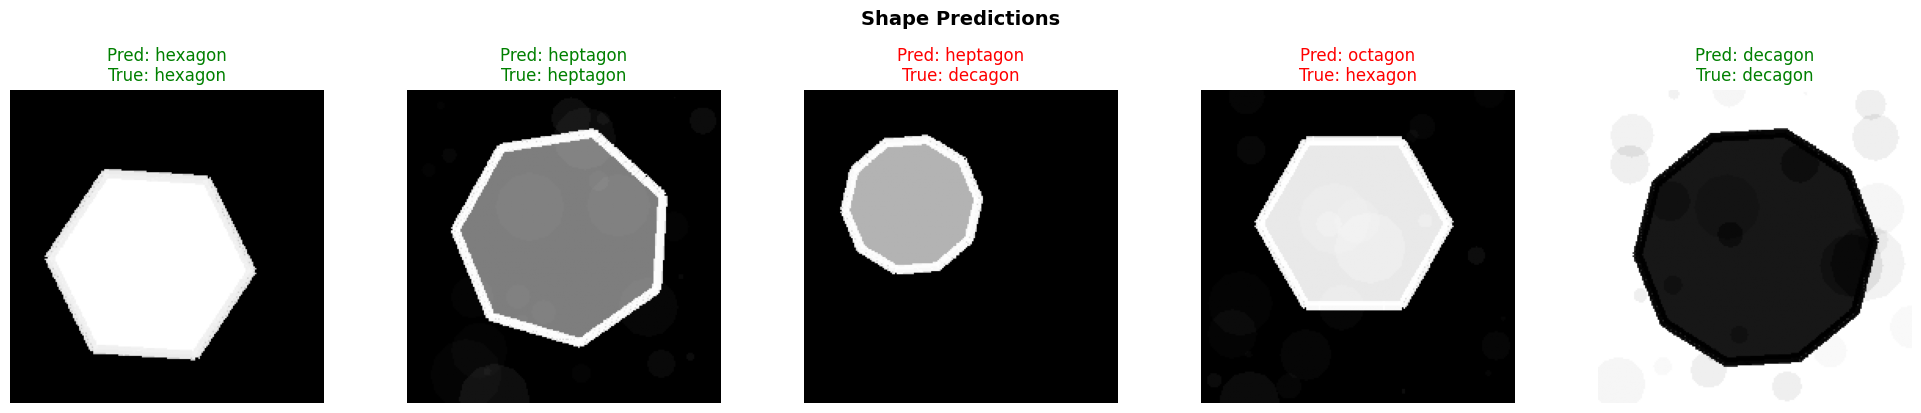

In [54]:
visualize_prediction(model, test_dataset, device, categories, num_samples=5)